# **Major Course Output**
**STINTSY Section S21**

Presented by: **Learning Models**
- Chan, Sidney Sy
- Hsu, Aldrin Gamad
- Siongco, Raine Margaux Aceret
- Villas, Gabriel


Dataset: **Student Performance** from _Using data mining to predict secondary school student performance_ (2008)

Task: **Predicting a student's alcohol consumption level**

Features: school, sex, age, address, fam_size, Pstatus, Medu, Fedu, Mjob, Fjob, reason, guardian,
traveltime, studytime, failures,
schoolsup, famsup, paid, activities, nursery, higher, internet, romantic,
freetime, goout, health, absences, G3


Label: alcohol_consumption (Average of Dalc and Walc)

In [3]:
# Imports
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
import torch.nn as nn
import numpy as np
import torch
import csv
import math
import pandas as pd

In [4]:
# To allow us to scroll through all the columns of our dataframes
pd.set_option('display.max_columns', None)

# Dataset Overview

school - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)

sex - student's sex (binary: 'F' - female or 'M' - male)

age - student's age (numeric: from 15 to 22)

address - student's home address type (binary: 'U' - urban or 'R' - rural)

famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)

Pstatus - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)

Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)

Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)

Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')

Fjob - father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')

reason - reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')

guardian - student's guardian (nominal: 'mother', 'father' or 'other')

traveltime - home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)

studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

failures - number of past class failures (numeric: n if 1<=n<3, else 4)

schoolsup - extra educational support (binary: yes or no)

famsup - family educational support (binary: yes or no)

paid - extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)

activities - extra-curricular activities (binary: yes or no)

nursery - attended nursery school (binary: yes or no)

higher - wants to take higher education (binary: yes or no)

internet - Internet access at home (binary: yes or no)

romantic - with a romantic relationship (binary: yes or no)

famrel - quality of family relationships (numeric: from 1 - very bad to 5 - excellent)

freetime - free time after school (numeric: from 1 - very low to 5 - very high)

goout - going out with friends (numeric: from 1 - very low to 5 - very high)

Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)

Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)

health - current health status (numeric: from 1 - very bad to 5 - very good)

absences - number of school absences (numeric: from 0 to 93)

[These grades are related with the course subject, Math or Portuguese:]
G1 - first period grade (numeric: from 0 to 20)

G2 - second period grade (numeric: from 0 to 20)

G3 - final grade (numeric: from 0 to 20, output target)

# Data Preparation

The **Student Performance** dataset from _Using data mining to predict secondary school student performance_ (2008) is comprised of two csv files, one for students who took Math and another for those who took Portuguese. To start, we import each of these as individual datasets.

In [5]:
# Importing datasets using csv files
student_math = pd.read_csv('student-mat.csv', sep=';')
student_port = pd.read_csv('student-por.csv', sep=';')

In [6]:
student_math.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [7]:
student_port.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


Based on the first few rows, both datasets seem to cover the exact same students, apart from the variables related to their chosen subject (failures, absences, G1, G2, and G3).

In [8]:
# To check both datasets for zero values
print("Math Dataset Zeros")
print((student_math == 0).sum())

print("\nPortuguese Dataset Zeros")
print((student_port == 0).sum())

Math Dataset Zeros
school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            3
Fedu            2
Mjob            0
Fjob            0
reason          0
guardian        0
traveltime      0
studytime       0
failures      312
schoolsup       0
famsup          0
paid            0
activities      0
nursery         0
higher          0
internet        0
romantic        0
famrel          0
freetime        0
goout           0
Dalc            0
Walc            0
health          0
absences      115
G1              0
G2             13
G3             38
dtype: int64

Portuguese Dataset Zeros
school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            6
Fedu            7
Mjob            0
Fjob            0
reason          0
guardian        0
traveltime      0
studytime       0
failures      549
schoolsup       0
famsup          0
paid            0
activities      0
nurser

In [9]:
# To check both datasets for missing values 
print("Math Dataset Missing Values")
print(student_math.isnull().sum())

print("\nPortuguese Dataset Missing Values")
print(student_port.isnull().sum())

Math Dataset Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Portuguese Dataset Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime    

# Exploratory Data Analysis

In [10]:
print("Math rows:", len(student_math))
print("Portuguese rows:", len(student_port))

Math rows: 395
Portuguese rows: 649


In [11]:
# Rename failures, absences, and G3 and remove G1 and G2 for both datasets
math_df = student_math.drop(columns=['G1', 'G2']).rename(columns={
    'G3': 'math_grade',
    'failures': 'math_failures',
    'absences': 'math_absences'
})

port_df = student_port.drop(columns=['G1', 'G2']).rename(columns={
    'G3': 'port_grade',
    'failures': 'port_failures',
    'absences': 'port_absences'
})

In [12]:
# Create combined_df by merging math_df and port_df on the stable columns
stable_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
               'traveltime', 'studytime', 'romantic', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
               'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'famrel']

combined_df = pd.merge(math_df, port_df, on=stable_cols, how='outer', suffixes=('_math', '_port'))
print("Combined rows:", len(combined_df))

Combined rows: 843


In [13]:
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,math_failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_absences,math_grade,port_failures,port_absences,port_grade
0,GP,F,15,R,GT3,T,1,1,at_home,other,home,mother,2,4,1.0,yes,yes,yes,yes,yes,yes,yes,no,3,1,2,1,1,1,2.0,10.0,0.0,4.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,course,mother,3,1,NaN,no,no,no,yes,yes,yes,yes,yes,5,5,5,1,1,1,NaN,NaN,1.0,2.0,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,reputation,mother,1,2,2.0,yes,yes,no,no,no,yes,yes,yes,3,3,4,2,4,5,2.0,5.0,0.0,2.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,NaN,yes,yes,no,yes,yes,yes,no,no,4,3,1,1,1,2,NaN,NaN,0.0,8.0,12.0
4,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,0.0,yes,yes,yes,yes,yes,yes,no,no,4,3,1,1,1,2,8.0,13.0,NaN,NaN,NaN
5,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,NaN,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,NaN,0.0,2.0,10.0
6,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,8.0,NaN,NaN,NaN
7,GP,F,15,R,GT3,T,3,3,services,services,reputation,other,2,3,2.0,no,yes,yes,yes,yes,yes,yes,yes,4,2,1,2,3,3,8.0,10.0,0.0,2.0,13.0
8,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,NaN,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,NaN,0.0,2.0,12.0
9,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,11.0,NaN,NaN,NaN


In [14]:
# Rearrange combined_df to make it more intuitive to read and work with
cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 
        'traveltime', 'studytime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 
        'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
        'math_failures', 'port_failures',
        'math_absences', 'port_absences',
        'math_grade', 'port_grade']

combined_df = combined_df[cols]

In [15]:
# View rearranged combined_df
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade
0,GP,F,15,R,GT3,T,1,1,at_home,other,home,mother,2,4,yes,yes,yes,yes,yes,yes,yes,no,3,1,2,1,1,1,1.0,0.0,2.0,4.0,10.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,course,mother,3,1,no,no,no,yes,yes,yes,yes,yes,5,5,5,1,1,1,NaN,1.0,NaN,2.0,NaN,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,reputation,mother,1,2,yes,yes,no,no,no,yes,yes,yes,3,3,4,2,4,5,2.0,0.0,2.0,2.0,5.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,yes,yes,no,yes,yes,yes,no,no,4,3,1,1,1,2,NaN,0.0,NaN,8.0,NaN,12.0
4,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,yes,yes,yes,yes,yes,yes,no,no,4,3,1,1,1,2,0.0,NaN,8.0,NaN,13.0,NaN
5,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,10.0
6,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,0.0,NaN,2.0,NaN,8.0,NaN
7,GP,F,15,R,GT3,T,3,3,services,services,reputation,other,2,3,no,yes,yes,yes,yes,yes,yes,yes,4,2,1,2,3,3,2.0,0.0,8.0,2.0,10.0,13.0
8,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,12.0
9,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,0.0,NaN,2.0,NaN,11.0,NaN


In [16]:
# Encoding for Yes/No Binary Categorical Variables
binary_cols = [
    "schoolsup","famsup","paid","activities",
    "nursery","higher","internet","romantic"
]

combined_df[binary_cols] = combined_df[binary_cols].replace({"yes":1, "no":0})

In [17]:
# Encoding for Other Binary Categorical Variables
combined_df["sex"] = combined_df["sex"].map({"F":0, "M":1})
combined_df["address"] = combined_df["address"].map({"R":0, "U":1})
combined_df["Pstatus"] = combined_df["Pstatus"].map({"A":0, "T":1})
combined_df["famsize"] = combined_df["famsize"].map({"LE3":0, "GT3":1})
combined_df["school"] = combined_df["school"].map({"GP":0, "MS":1})

In [18]:
# Encoding for Categorical Variables with More than 2 Categories
combined_df = pd.get_dummies(
    combined_df,
    columns=["Mjob","Fjob","reason","guardian"],
    drop_first=True
)

In [19]:
# View latest combined_df
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,15,0,1,1,1,1,2,4,1,1,1,1,1,1,1,0,3,1,2,1,1,1,1.0,0.0,2.0,4.0,10.0,13.0,False,False,False,False,False,True,False,False,True,False,False,True,False
1,0,0,15,0,1,1,1,1,3,1,0,0,0,1,1,1,1,1,5,5,5,1,1,1,NaN,1.0,NaN,2.0,NaN,9.0,False,True,False,False,False,True,False,False,False,False,False,True,False
2,0,0,15,0,1,1,1,1,1,2,1,1,0,0,0,1,1,1,3,3,4,2,4,5,2.0,0.0,2.0,2.0,5.0,11.0,False,True,False,False,False,True,False,False,False,False,True,True,False
3,0,0,15,0,1,1,2,2,1,1,1,1,0,1,1,1,0,0,4,3,1,1,1,2,NaN,0.0,NaN,8.0,NaN,12.0,False,False,False,False,False,True,False,False,False,False,True,True,False
4,0,0,15,0,1,1,2,2,1,1,1,1,1,1,1,1,0,0,4,3,1,1,1,2,0.0,NaN,8.0,NaN,13.0,NaN,False,False,False,False,False,True,False,False,False,False,True,True,False
5,0,0,15,0,1,1,2,4,1,3,1,1,0,1,1,1,1,0,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,10.0,False,False,True,False,True,False,False,False,False,False,False,True,False
6,0,0,15,0,1,1,2,4,1,3,1,1,1,1,1,1,1,0,4,3,2,1,1,5,0.0,NaN,2.0,NaN,8.0,NaN,False,False,True,False,True,False,False,False,False,False,False,True,False
7,0,0,15,0,1,1,3,3,2,3,0,1,1,1,1,1,1,1,4,2,1,2,3,3,2.0,0.0,8.0,2.0,10.0,13.0,False,False,True,False,False,False,True,False,False,False,True,False,True
8,0,0,15,0,1,1,3,4,1,3,1,1,0,1,1,1,1,0,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,12.0,False,False,True,False,True,False,False,False,False,False,False,True,False
9,0,0,15,0,1,1,3,4,1,3,1,1,1,1,1,1,1,0,4,3,2,1,1,5,0.0,NaN,2.0,NaN,11.0,NaN,False,False,True,False,True,False,False,False,False,False,False,True,False


In [20]:
# For resolving NaN values for students who only took one of the two subjects   
# Indicator variables on if they took Math and/or Portuguese
combined_df["took_math"] = combined_df["math_grade"].notna().astype(int)
combined_df["took_port"] = combined_df["port_grade"].notna().astype(int)

# Fill NaNs for absences, failures, and grades with 0s
combined_df["math_absences"] = combined_df["math_absences"].fillna(0)
combined_df["port_absences"] = combined_df["port_absences"].fillna(0)

combined_df["math_failures"] = combined_df["math_failures"].fillna(0)
combined_df["port_failures"] = combined_df["port_failures"].fillna(0)

combined_df["math_grade"] = combined_df["math_grade"].fillna(0)
combined_df["port_grade"] = combined_df["port_grade"].fillna(0)

In [21]:
# Create new column (alcohol_consumption) by averaging Dalc and Walc, then remove Dalc and Walc
combined_df["alcohol_consumption"] = (combined_df["Dalc"] + combined_df["Walc"]) / 2
combined_df = combined_df.drop(columns=["Dalc", "Walc"])

In [22]:
#COnvert columns with True/False values to 1/0
bool_cols = combined_df.select_dtypes(include="bool").columns
combined_df[bool_cols] = combined_df[bool_cols].astype(int)

In [23]:
# View latest combined_df
combined_df.tail(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,took_math,took_port,alcohol_consumption
833,1,1,19,0,1,1,1,1,3,1,0,1,0,0,1,1,1,0,4,4,4,5,1.0,1.0,4.0,4.0,8.0,10.0,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,3.0
834,1,1,19,0,1,1,1,1,3,2,0,0,0,0,1,1,1,0,5,4,4,2,3.0,1.0,8.0,8.0,8.0,11.0,0,1,0,0,0,0,1,0,1,0,0,0,1,1,1,3.0
835,1,1,19,0,1,1,1,1,2,1,0,0,0,0,1,1,0,0,4,3,2,5,1.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,1,0,1,0,1,1,2.0
836,1,1,19,1,1,1,1,1,1,2,0,1,0,1,1,0,1,0,4,4,3,4,0.0,2.0,0.0,2.0,0.0,10.0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,3.5
837,1,1,19,1,1,1,2,1,2,1,0,0,0,1,0,0,1,1,4,4,3,5,0.0,3.0,0.0,4.0,0.0,9.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,2.0
838,1,1,19,1,1,1,3,2,2,1,0,0,0,1,1,1,0,0,3,2,1,3,0.0,3.0,0.0,4.0,0.0,9.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1.0
839,1,1,19,1,0,1,1,1,1,1,0,0,0,0,1,1,1,0,3,2,3,5,0.0,0.0,5.0,0.0,9.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3.0
840,1,1,20,0,1,1,1,1,2,1,0,1,0,0,1,0,1,1,4,4,3,4,0.0,1.0,0.0,12.0,0.0,10.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,3.0
841,1,1,20,1,0,0,2,2,1,2,0,1,1,0,1,1,0,0,5,5,4,4,2.0,0.0,11.0,0.0,9.0,0.0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,4.5
842,1,1,21,0,1,1,1,1,1,1,0,0,0,0,0,1,0,0,5,5,3,3,3.0,0.0,3.0,0.0,7.0,0.0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,3.0


## Statistical Summary

In [24]:
# Statistical summary of all numeric features
combined_df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,took_math,took_port,alcohol_consumption
count,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.00000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000
mean,0.293001,0.411625,16.763938,0.722420,0.699881,0.883749,2.588375,2.360617,1.52669,1.976275,3.935943,3.176750,3.169632,3.524318,0.156584,0.170819,2.674970,2.817319,4.880190,9.166074,0.079478,0.377224,0.227758,0.124555,0.040332,0.568209,0.276394,0.053381,0.240807,0.109134,0.238434,0.702254,0.074733,0.468565,0.769870,1.889680
std,0.455409,0.492420,1.235858,0.448071,0.458581,0.320717,1.132633,1.095430,0.72465,0.835329,0.930188,1.043396,1.148552,1.439291,0.535366,0.528749,6.172206,4.353155,6.071711,5.759919,0.270644,0.484979,0.419635,0.330410,0.196854,0.495620,0.447479,0.224925,0.427827,0.311992,0.426379,0.457539,0.263116,0.499307,0.421166,0.983377
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,0.000000,0.000000,17.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.00000,2.000000,4.000000,3.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.500000
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.00000,2.000000,5.000000,4.000000,4.000000,5.000000,0.000000,0.000000,3.000000,4.000000,10.000000,13.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.500000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.00000,4.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,75.000000,32.000000,20.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000


## Label Distribution

We examine the distribution of `alcohol_consumption` (the average of `Dalc` and `Walc`). Since the values range from 1.0 to 5.0 in 0.5 increments, this is effectively an ordinal label. Understanding the class distribution is critical to detecting imbalance before modeling.

Value counts for alcohol_consumption:
alcohol_consumption
1.0    309
1.5    150
2.0    134
2.5     97
3.0     67
3.5     37
4.0     22
4.5     10
5.0     17
Name: count, dtype: int64


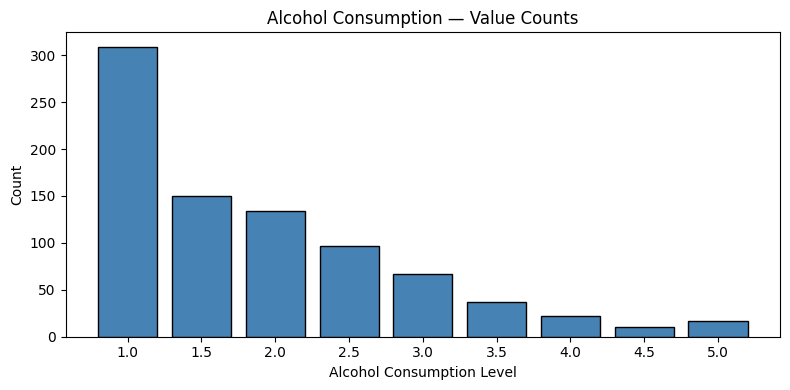

In [25]:
# Distribution of alcohol_consumption values (bar chart only)
print("Value counts for alcohol_consumption:")
val_counts = combined_df["alcohol_consumption"].value_counts().sort_index()
print(val_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(val_counts.index.astype(str), val_counts.values, color="steelblue", edgecolor="black")
ax.set_title("Alcohol Consumption — Value Counts")
ax.set_xlabel("Alcohol Consumption Level")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Most students fall at the lower end of the alcohol consumption scale — the 1.0 and 1.5 levels account for the majority of the data. The distribution drops off sharply at higher levels (3.5–5.0), indicating significant class imbalance that will need to be addressed during model training, such as through oversampling or class weighting.

## Feature Distributions

We examine the distributions of key numeric features to spot skewness, outliers, or unusual patterns.

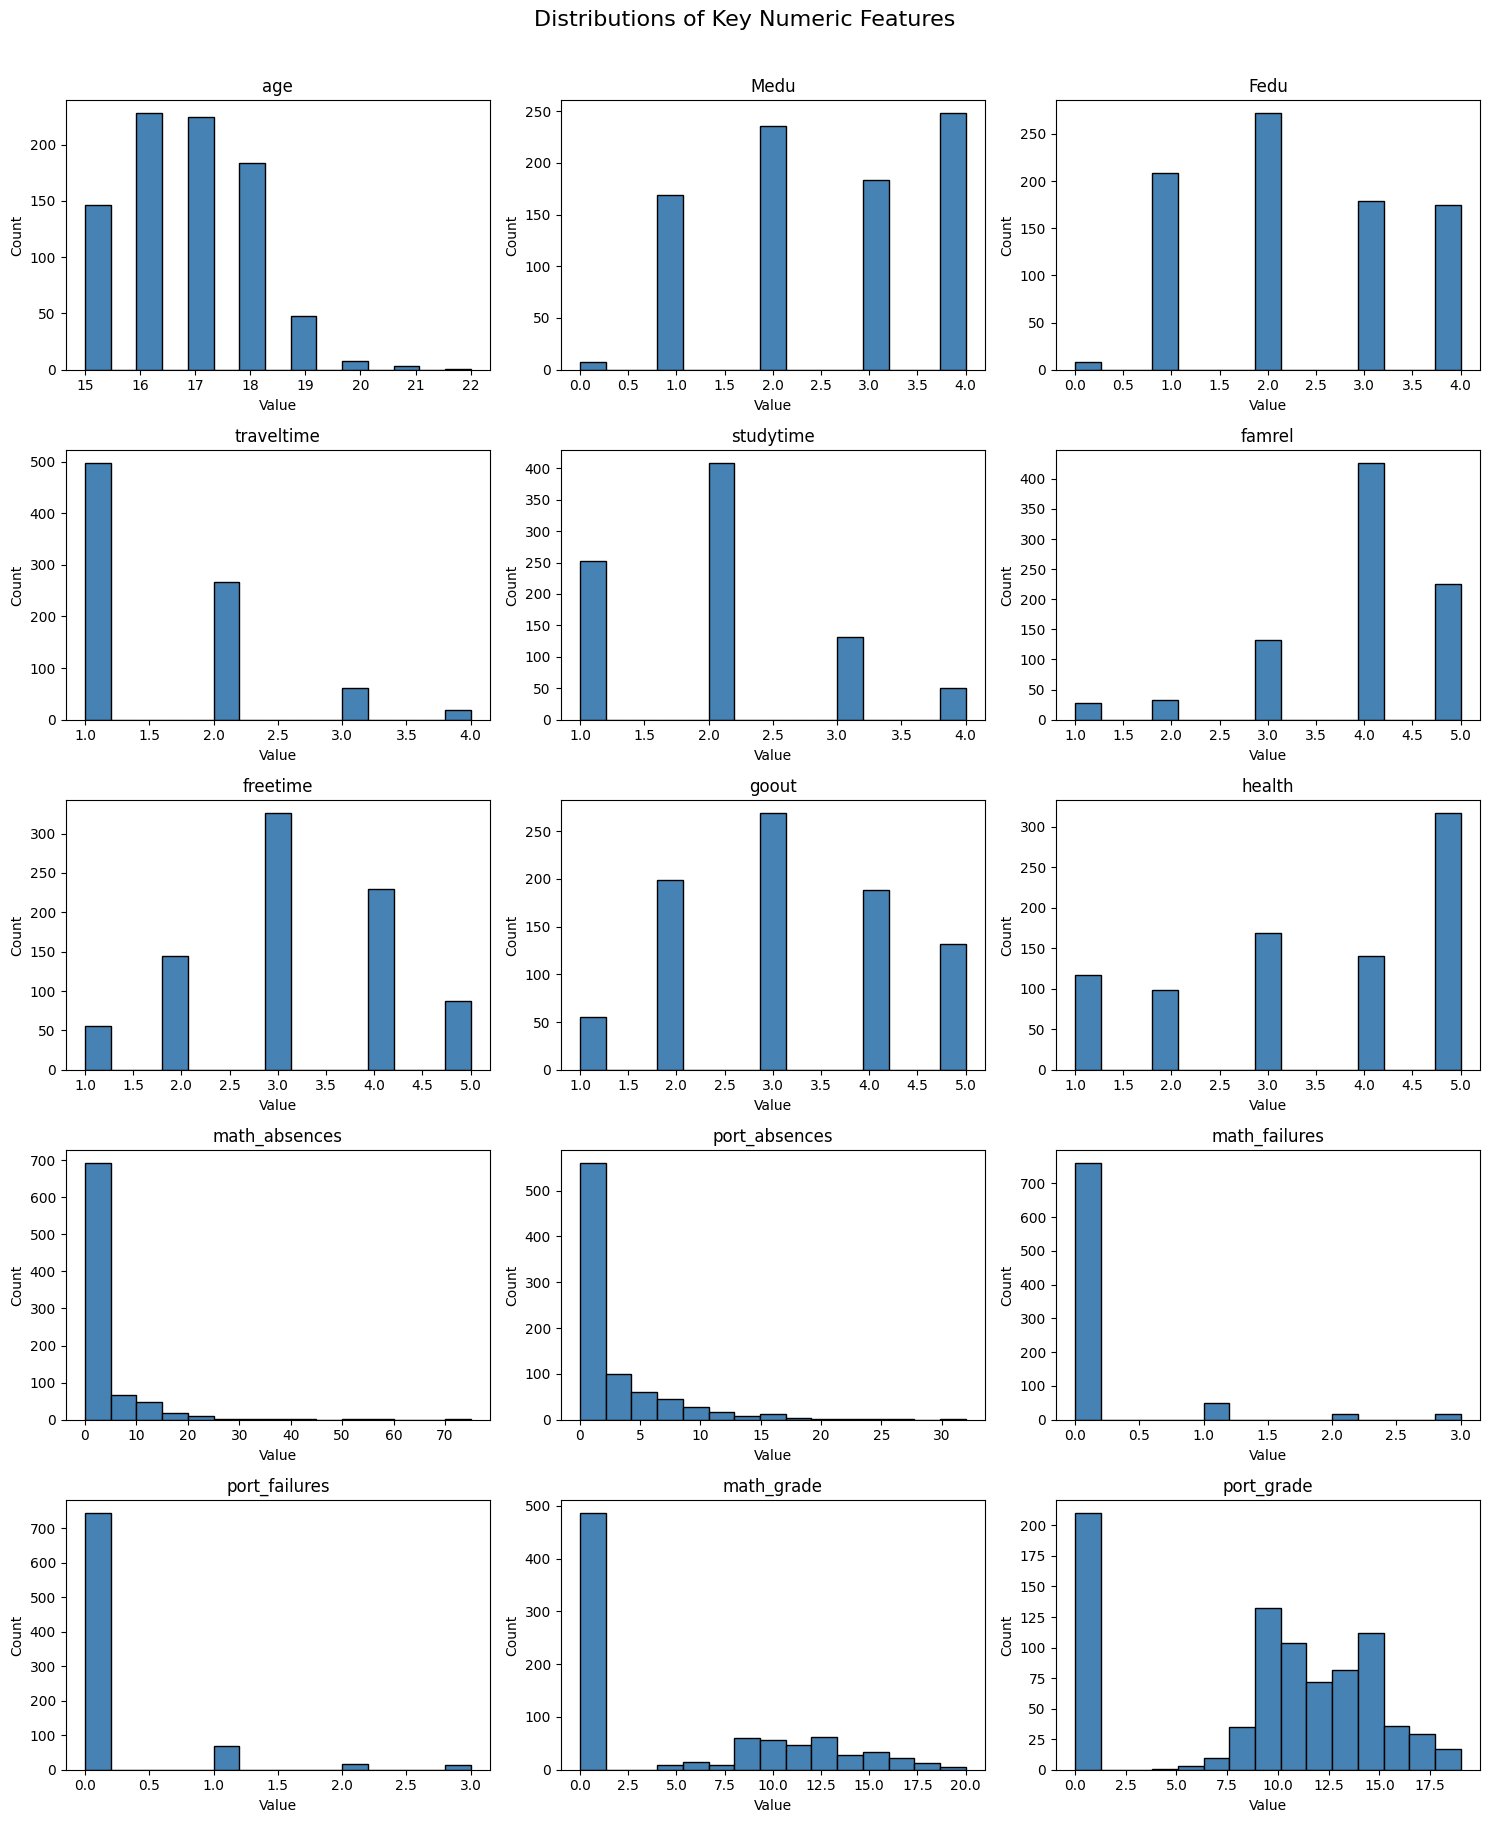

In [26]:
# Histograms for key numeric features
numeric_features = ["age", "Medu", "Fedu", "traveltime", "studytime",
                    "famrel", "freetime", "goout", "health",
                    "math_absences", "port_absences",
                    "math_failures", "port_failures",
                    "math_grade", "port_grade"]

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(combined_df[col].dropna(), bins=15, edgecolor="black", color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distributions of Key Numeric Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Several numeric features show skewed or clustered distributions. Absence columns (`math_absences`, `port_absences`) are heavily right-skewed, with most students having few or no absences and a small number having very high counts. Grade columns (`math_grade`, `port_grade`) show a left-leaning peak around 10–12, while ordinal features like `studytime` and `traveltime` cluster at the lower levels. These patterns suggest that normalization and outlier handling may be beneficial before modeling.

## Categorical Feature Distributions

We examine the distribution of categorical features to understand how students are distributed across groups such as sex, school, and address.

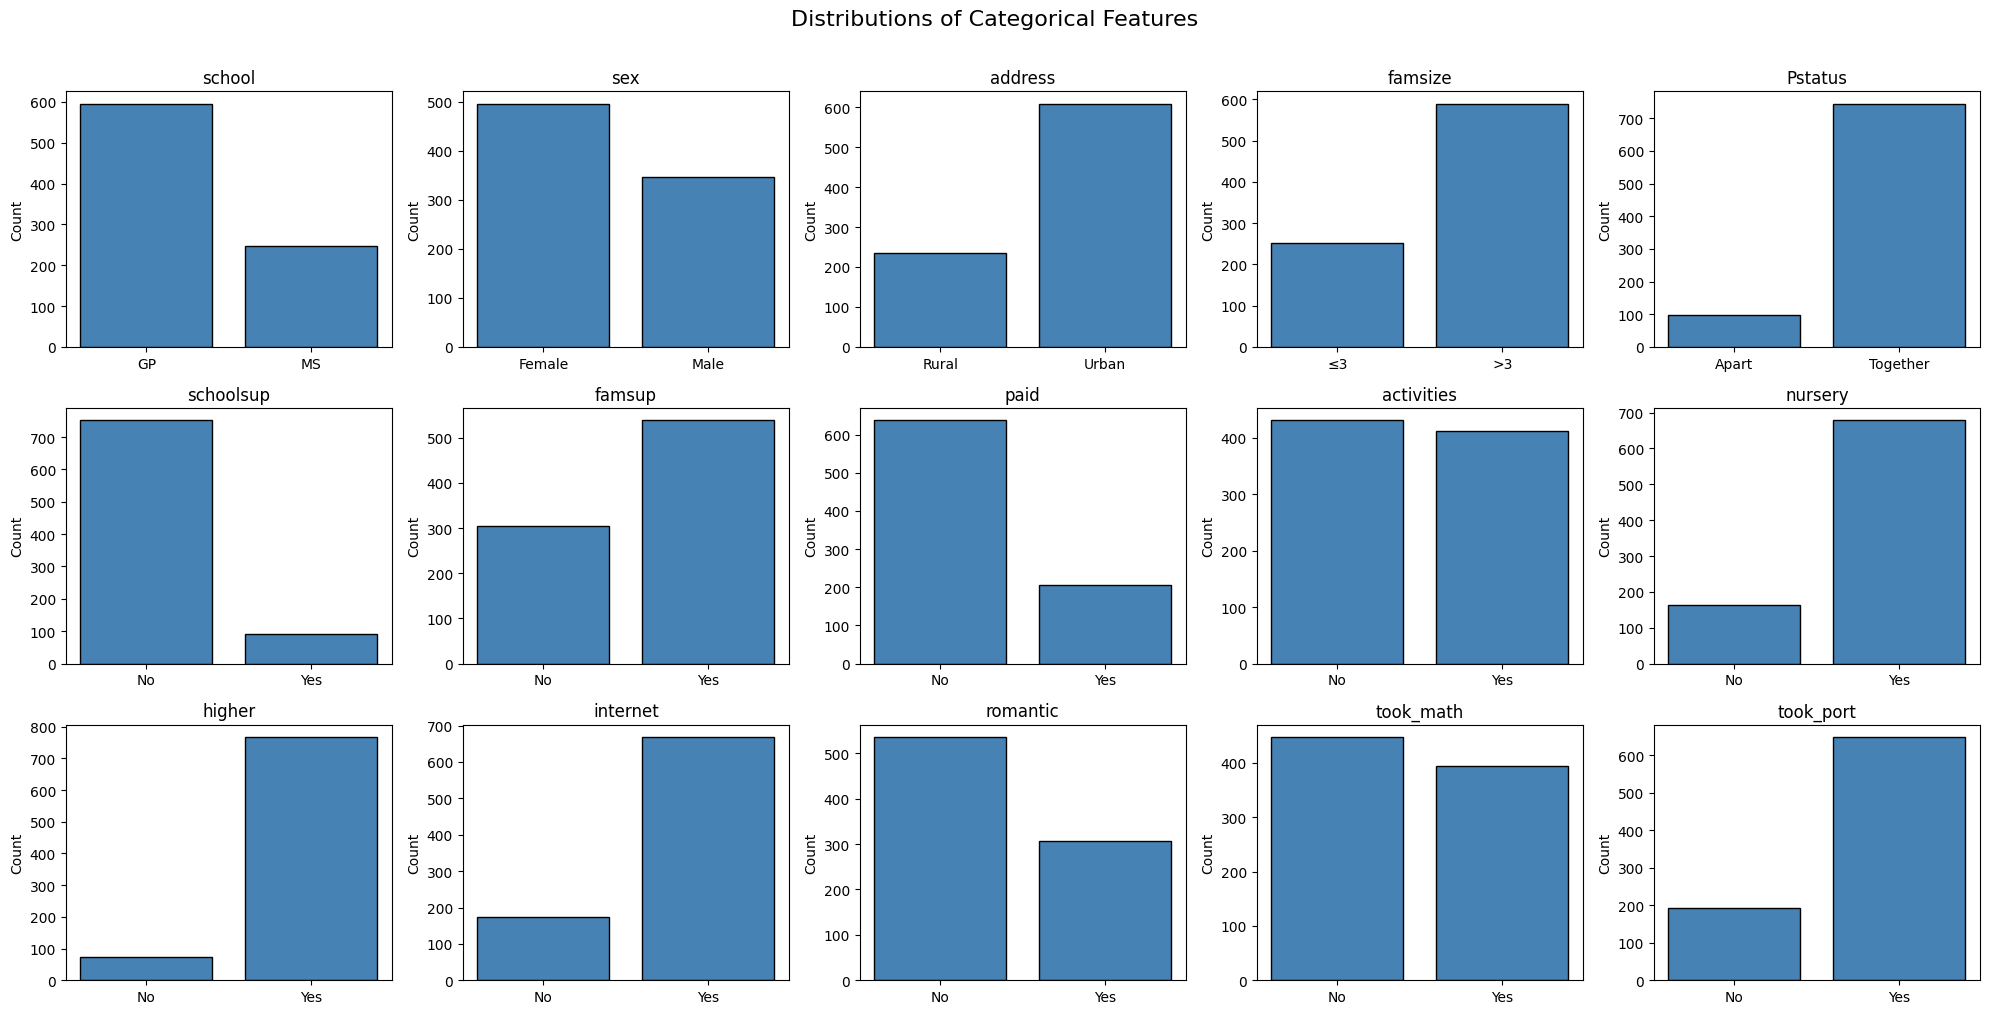

In [27]:
# Bar charts for binary/encoded categorical features
categorical_features = ["school", "sex", "address", "famsize", "Pstatus",
                        "schoolsup", "famsup", "paid", "activities",
                        "nursery", "higher", "internet", "romantic",
                        "took_math", "took_port"]

label_maps = {
    "school":    {0: "GP", 1: "MS"},
    "sex":       {0: "Female", 1: "Male"},
    "address":   {0: "Rural", 1: "Urban"},
    "famsize":   {0: "≤3", 1: ">3"},
    "Pstatus":   {0: "Apart", 1: "Together"},
}
binary_01 = ["schoolsup", "famsup", "paid", "activities",
             "nursery", "higher", "internet", "romantic",
             "took_math", "took_port"]
for col in binary_01:
    label_maps[col] = {0: "No", 1: "Yes"}

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    counts = combined_df[col].value_counts().sort_index()
    labels = [label_maps[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(labels, counts.values, color="steelblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Distributions of Categorical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Category frequencies are notably uneven across several features. The majority of students come from school GP, live in urban areas, and have family sizes greater than 3. For binary features, most students have internet access at home and aspire to pursue higher education, while fewer report having a romantic relationship or receiving extra school support. These imbalances can skew learned decision boundaries, so they should be kept in mind during feature selection and model evaluation.

## Alcohol Consumption by Key Categorical Groups

We compare average alcohol consumption across important categorical groups to identify which groups tend to drink more.

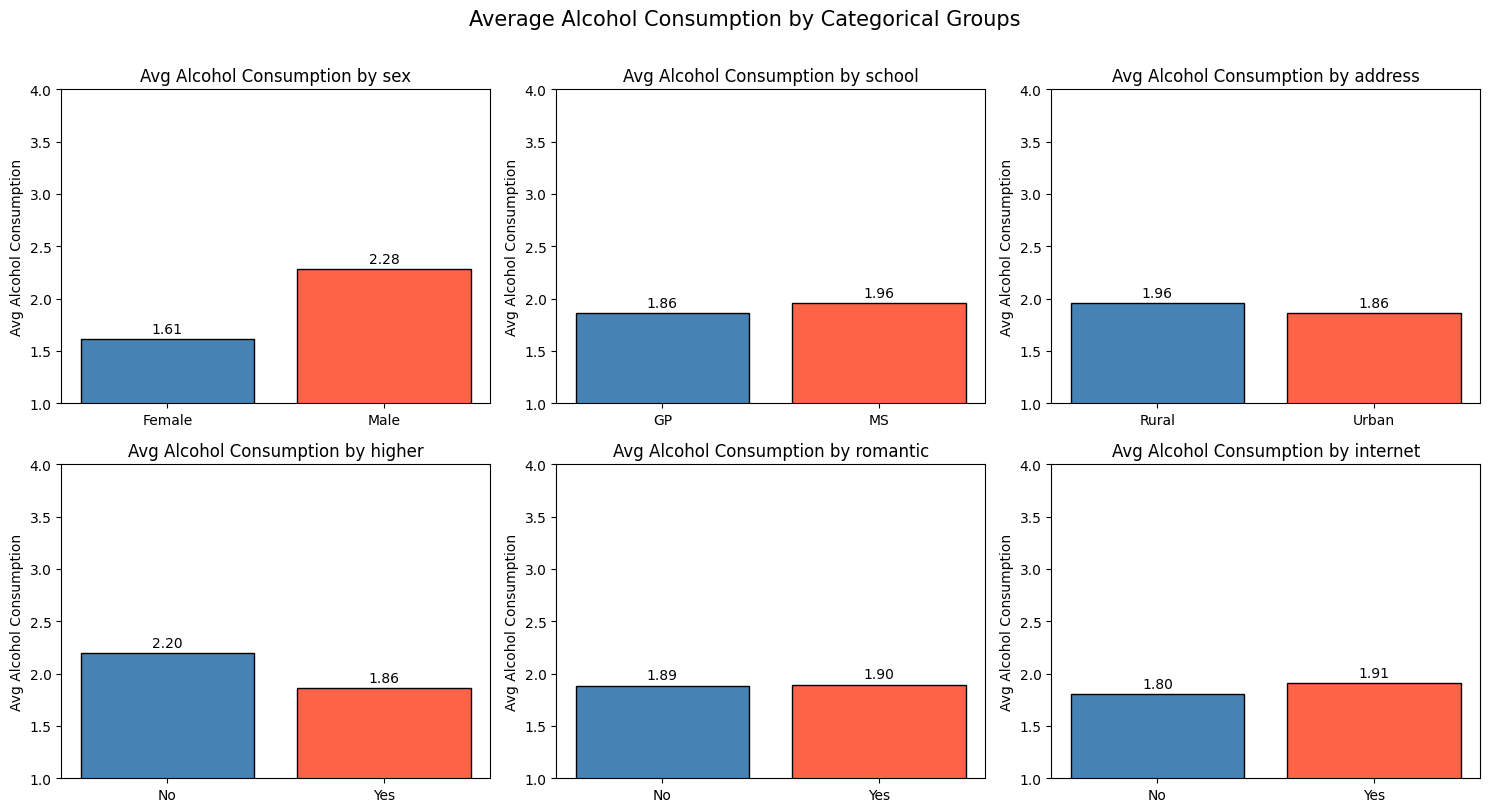

In [28]:
# Average alcohol consumption by key categorical groups
group_cols = {
    "sex":      {0: "Female", 1: "Male"},
    "school":   {0: "GP", 1: "MS"},
    "address":  {0: "Rural", 1: "Urban"},
    "higher":   {0: "No", 1: "Yes"},
    "romantic": {0: "No", 1: "Yes"},
    "internet": {0: "No", 1: "Yes"},
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, lmap) in enumerate(group_cols.items()):
    group_means = combined_df.groupby(col)["alcohol_consumption"].mean()
    labels = [lmap.get(k, str(k)) for k in group_means.index]
    bars = axes[i].bar(labels, group_means.values, color=["steelblue", "tomato"], edgecolor="black")
    axes[i].set_title(f"Avg Alcohol Consumption by {col}")
    axes[i].set_ylabel("Avg Alcohol Consumption")
    axes[i].set_ylim(1, 4)
    for bar, val in zip(bars, group_means.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Average Alcohol Consumption by Categorical Groups", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Based on the charts, male students report a notably higher average alcohol consumption (2.28) compared to female students (1.61). Additionally, students who do not plan to pursue higher education have a higher average alcohol consumption (2.20) than those who do (1.86), while other factors like school, address, romantic status, and internet access show very minimal differences.

## Alcohol Consumption vs. Ordinal Features

We use line graphs to show how the average alcohol consumption changes across ordinal feature levels like `goout`, `freetime`, `studytime`, and `health`.

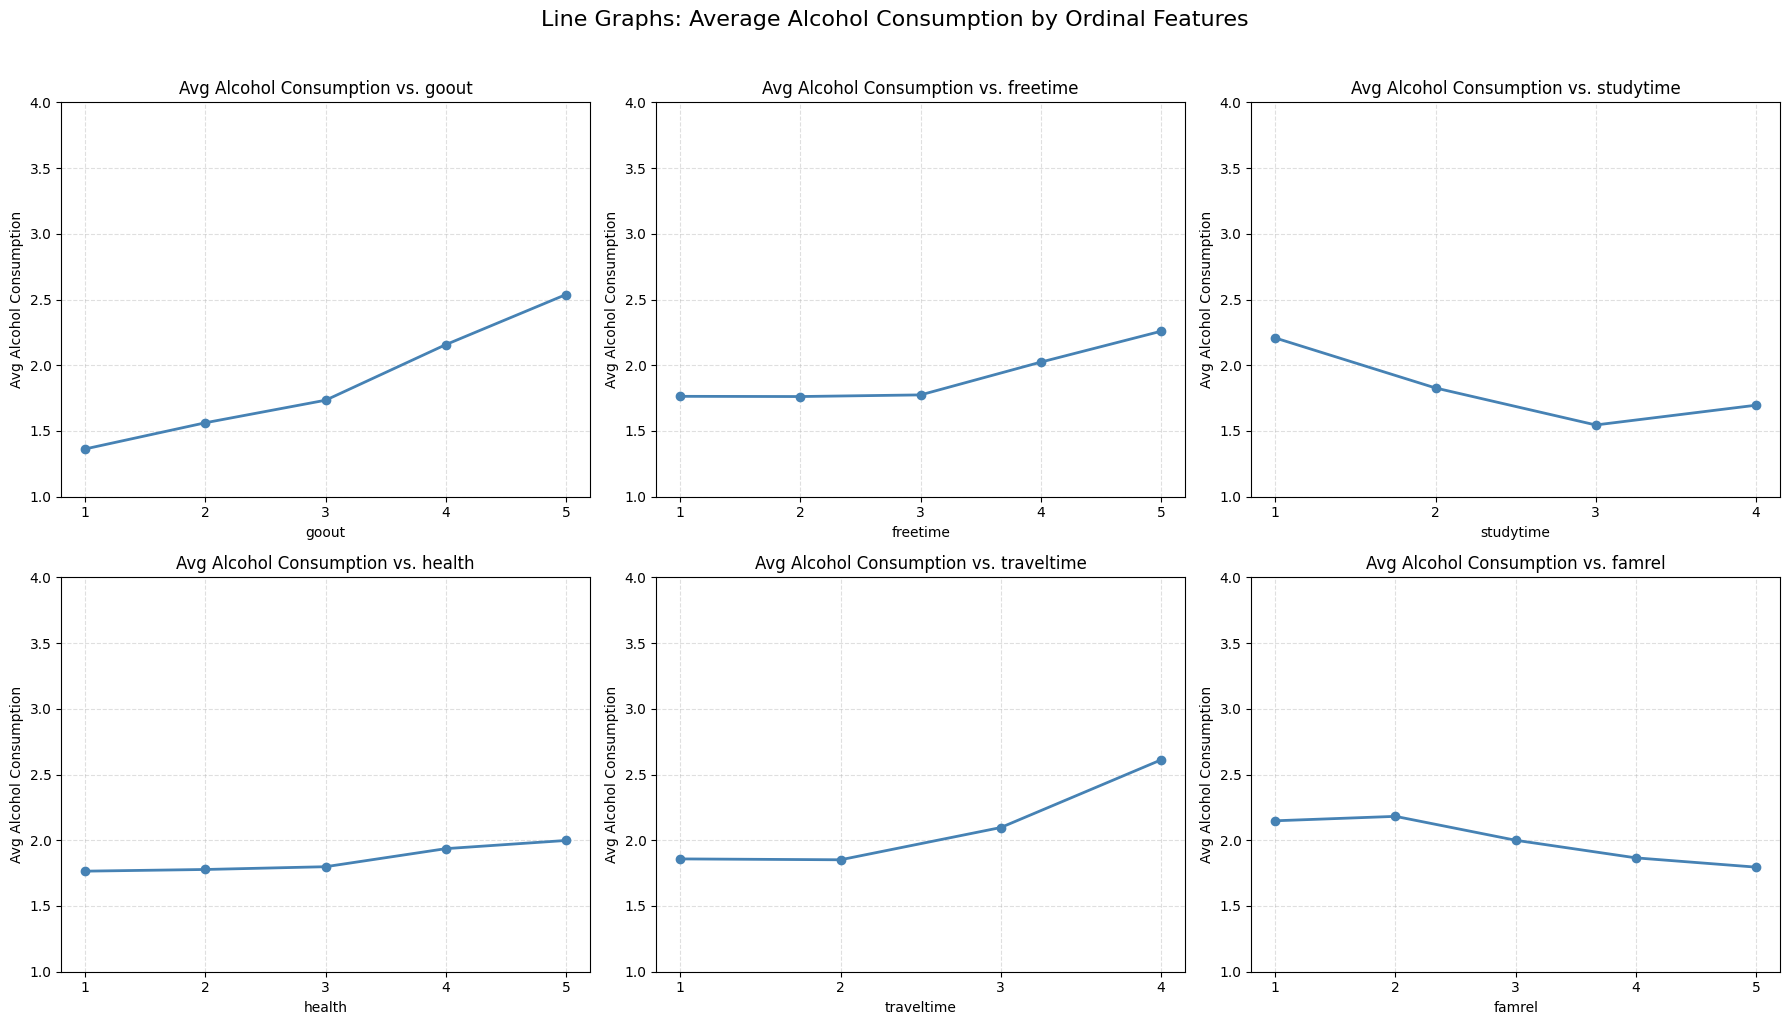

In [37]:
# Line graphs: average alcohol_consumption vs. ordinal feature levels
ordinal_features = ["goout", "freetime", "studytime", "health", "traveltime", "famrel"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(ordinal_features):
    mean_by_level = combined_df.groupby(col)["alcohol_consumption"].mean().sort_index()
    axes[i].plot(
        mean_by_level.index,
        mean_by_level.values,
        marker="o",
        linewidth=2,
        color="steelblue"
    )
    axes[i].set_title(f"Avg Alcohol Consumption vs. {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Avg Alcohol Consumption")
    axes[i].set_ylim(1, 4)
    axes[i].set_xticks(mean_by_level.index)
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Line Graphs: Average Alcohol Consumption by Ordinal Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The line graphs reveal clear directional trends for some features. `goout` (going out with friends) shows a consistent upward trend — students who go out more frequently report higher average alcohol consumption across all levels. `studytime` shows the opposite pattern, with higher study hours associated with lower average consumption. `freetime` also trends upward moderately. In contrast, `health`, `famrel`, and `traveltime` show relatively flat or inconsistent patterns, suggesting weaker relationships with alcohol consumption.

## Correlation Heatmap

We compute the Pearson correlation matrix for all numeric features with respect to `alcohol_consumption`. This helps identify which features are most strongly related to the label and whether any features are redundant (highly correlated with each other).

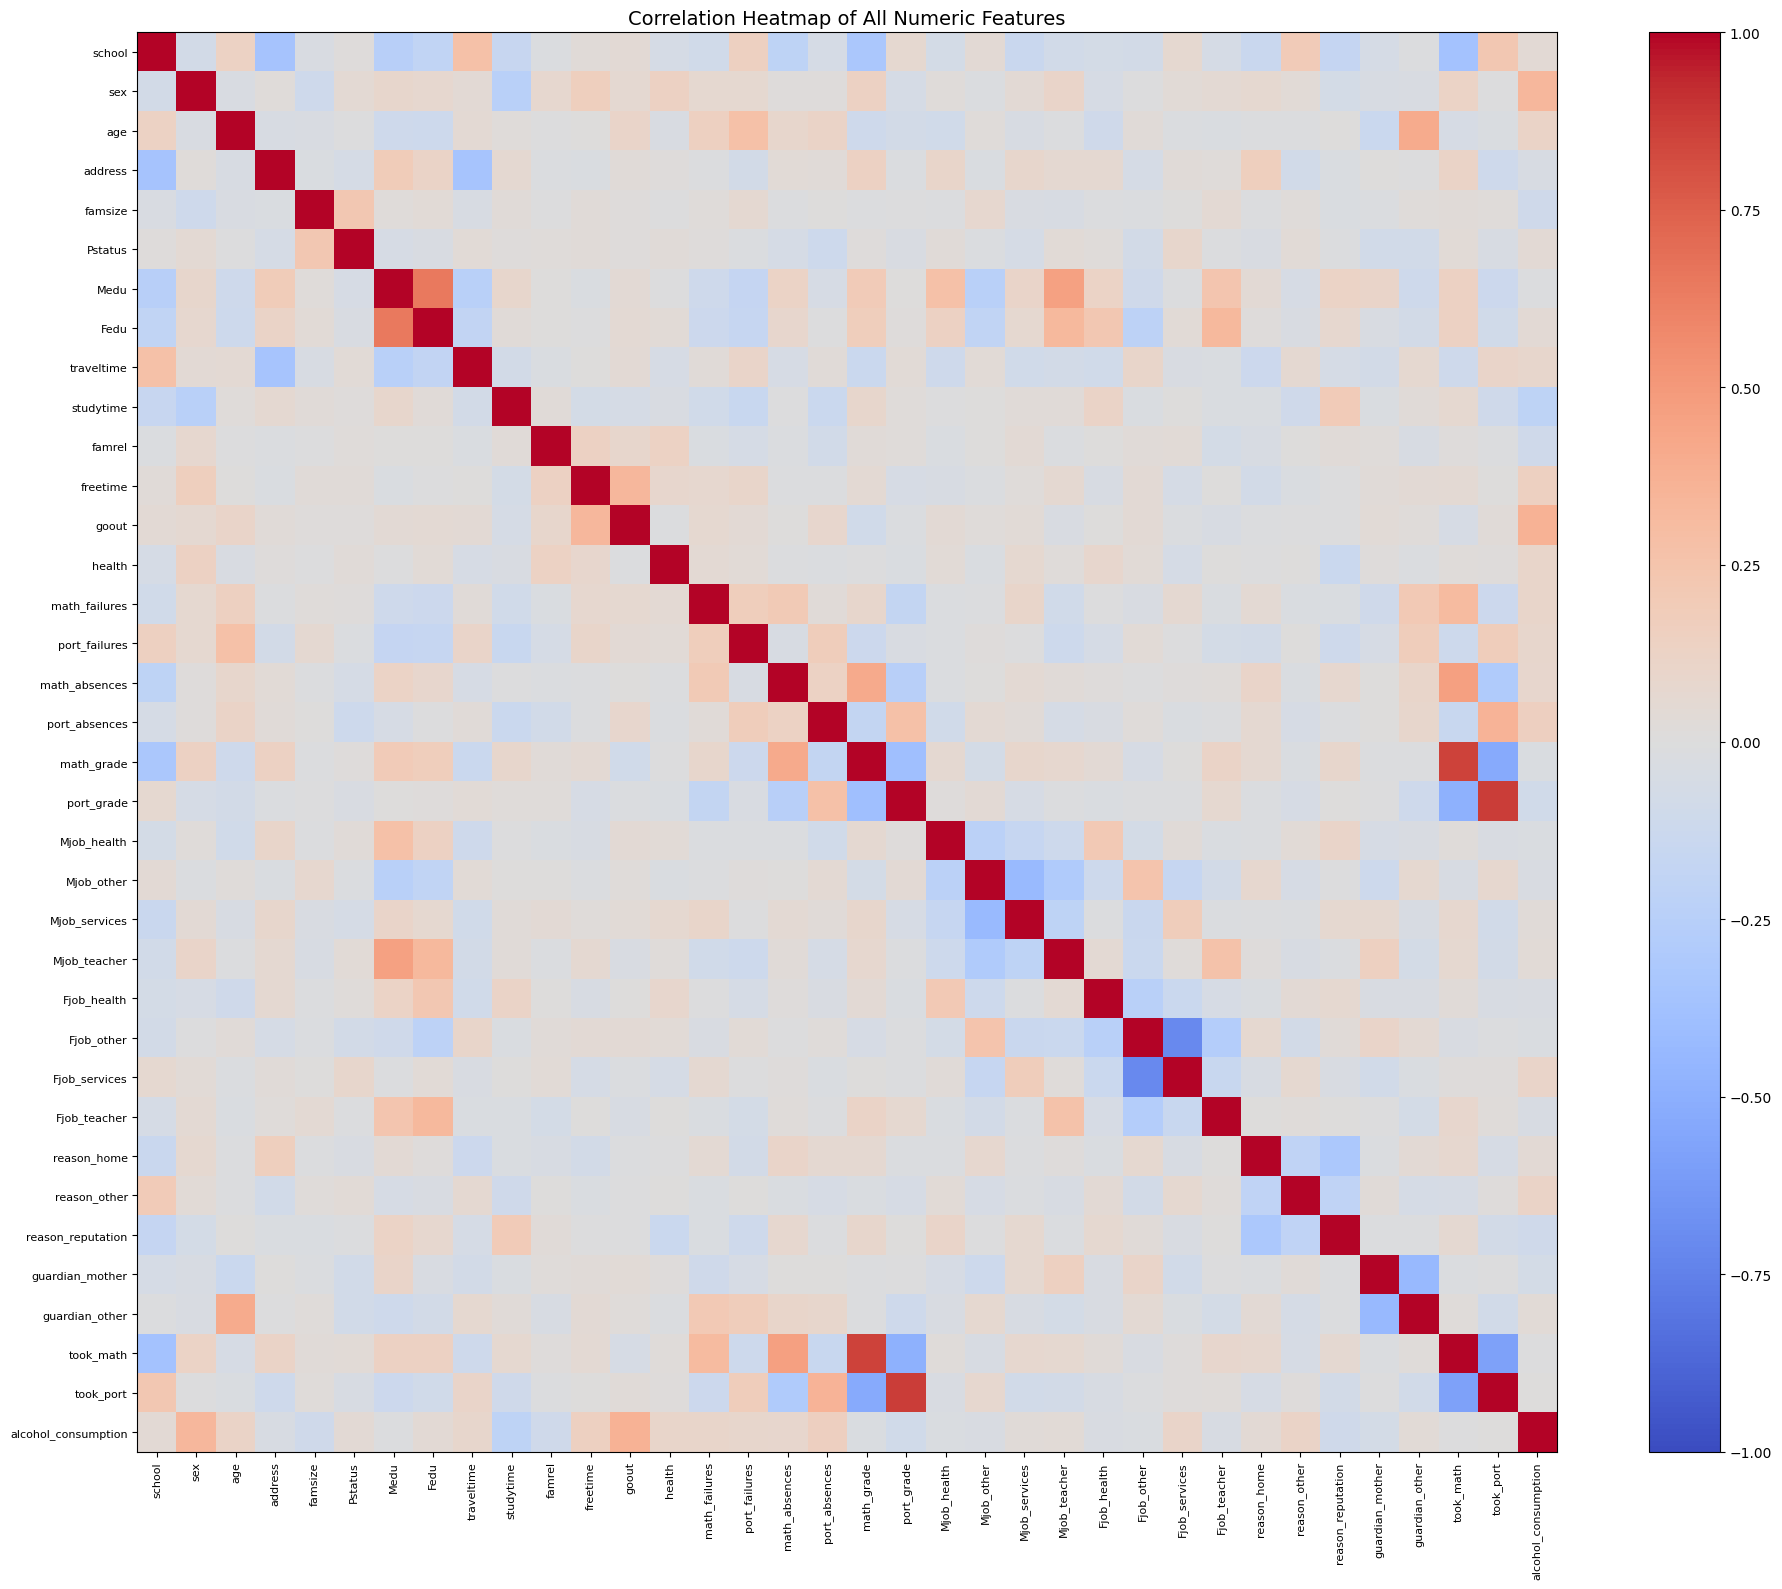

In [30]:
# Correlation heatmap of all numeric columns
numeric_df = combined_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
ax.set_title("Correlation Heatmap of All Numeric Features", fontsize=14)

plt.tight_layout()
plt.show()

The heatmap reveals that most features have weak to moderate correlations with `alcohol_consumption`. A few features stand out with stronger positive correlations (notably `goout` and `freetime`), while `studytime` and `higher` show negative correlations. Some feature pairs also show moderate correlation with each other — for example, `Medu` and `Fedu` (parental education levels), and math vs. Portuguese grade columns — which may introduce redundancy and should be considered during feature selection.

Top 15 features most correlated with alcohol_consumption:
goout                0.362012
sex                  0.335473
studytime            0.209940
port_absences        0.151622
freetime             0.147508
age                  0.115848
reason_other         0.110902
Fjob_services        0.105811
math_failures        0.099399
reason_reputation    0.098644
famrel               0.098620
health               0.097137
famsize              0.094576
traveltime           0.090802
port_failures        0.089963


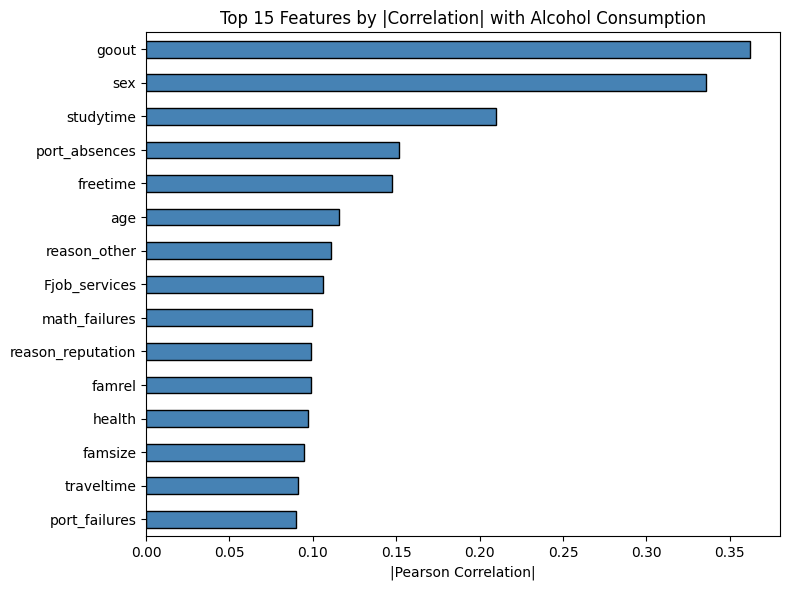

In [31]:
# Top features correlated with alcohol_consumption (sorted by absolute correlation)
alcohol_corr = corr_matrix["alcohol_consumption"].drop("alcohol_consumption").abs().sort_values(ascending=False)

print("Top 15 features most correlated with alcohol_consumption:")
print(alcohol_corr.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
alcohol_corr.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Features by |Correlation| with Alcohol Consumption")
ax.set_xlabel("|Pearson Correlation|")
plt.tight_layout()
plt.show()

`goout` ranks as the most correlated feature with `alcohol_consumption`, followed by `freetime` and `studytime`. The top features are dominated by lifestyle and behavioral variables, while demographic and grade-related features tend to rank lower. This suggests that a student's social habits are more predictive of alcohol consumption than academic performance or family background alone. These top-ranked features are strong candidates for inclusion in initial model experiments.

## EDA Summary

Based on the analysis above, we note the following key observations:

- **Label distribution**: `alcohol_consumption` is right-skewed — the 1.0 and 1.5 levels account for the majority of students, and the distribution drops off sharply at higher levels (3.5–5.0). This **class imbalance** must be addressed during model training, such as through oversampling or class weighting.
- **Sex effect**: Male students report a notably higher average alcohol consumption (2.28) compared to female students (1.61), making `sex` one of the most distinguishing categorical features.
- **Higher education aspirations**: Students who do not plan to pursue higher education have a higher average alcohol consumption (2.20) than those who do (1.86). Other categorical groups — school, address, romantic status, and internet access — show minimal differences.
- **Strongest correlates**: `goout` ranks as the most positively correlated feature with `alcohol_consumption`, followed by `freetime`. `studytime` shows a consistent negative trend, and `higher` also correlates negatively. Lifestyle and behavioral features dominate the top correlates, while academic and demographic features rank lower.
- **Ordinal feature trends**: `goout` and `freetime` both trend upward with alcohol consumption, while `studytime` trends downward. `health`, `famrel`, and `traveltime` show relatively flat or inconsistent patterns across levels.
- **Grades and absences**: Both math and Portuguese grades show a mild negative correlation with alcohol consumption, while total absences show a mild positive correlation. However, scatter plots confirm considerable overlap — no single feature cleanly separates consumption levels.
- **No missing values** were found in the final merged dataset after preprocessing.

These observations will inform **feature selection** and the choice of **class binning strategy** in the next step.